# Método de Euler

Si se piensa en una ecuación diferencial como un campo de pendientes. La geometría sugiere que un enfoque alternativo de resolver computacionalmente la ecuación diferencial es siguiendo las feclas . Comience en la condición inicial $(t_0,y_0)$ y siga la dirección específicada allí. Despúes desplace una distancia corta, vuelva a evaluar la pendiente en el punto nuevo, aléjese aún más de acuerdo con la nueva pendiente y repita el proceso. Habá un error asociado con el proceso, puesto que, entre evaluaciones de la pendiente, no se moverá a lo largo de una pendiente totalmente exacta.

<center>

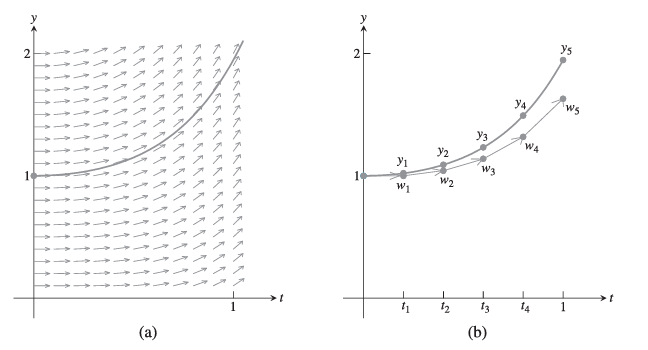

<center>

La aproximación es:

$$w_{i+1} = w_i + hf(t_i, w_i)$$

La fórmula para el método de Euler es entonces:

$$w_0 = y_0$$

$$w_{i+1} = w_i + hf(t_i, w_i)$$



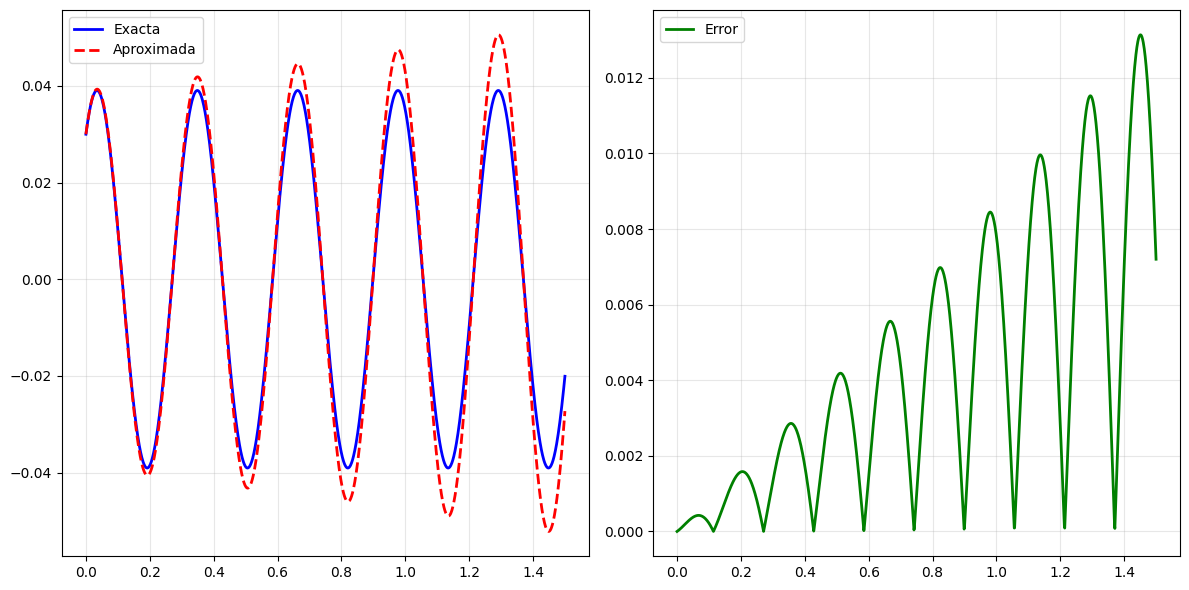

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def sistema(Y0, t):
    Y1, Y2 = Y0
    DY1 = Y2
    DY2 = -(20)**2*Y1

    return np.array([DY1, DY2])

def Euler(sistema, a, b, h, Y0):

    t = np.arange(a, b + h, h)
    n = t.shape[0]
    Y = np.zeros((n, Y0.shape[0]))

    Y[0, :] = Y0

    for i in range(n-1):

        Y[i+1,:] = Y[i,:] + h*sistema(Y[i,:], t[i])

    return Y, t

Y0 = np.array([0.03, 0.5])

Y, t = Euler(sistema, 0, 1.5, 0.001, Y0)

def exacta(t):
    return 0.03*np.cos(20*t) + (0.5/20)*np.sin(20*t)

Y_e = exacta(t)

error = np.abs(Y[:,0] - Y_e)

fig, ax = plt.subplots(1,2,figsize = (12,6))

ax[0].plot(t, Y_e, c = 'blue', lw = 2, label = 'Exacta')
ax[0].plot(t, Y[:,0], c = 'red', lw = 2, ls = '--', label = 'Aproximada')
ax[0].legend()

ax[0].grid(alpha = 0.3)

ax[1].plot(t, error, c = 'green', lw = 2, label = 'Error')
ax[1].legend()

ax[1].grid(alpha = 0.3)
plt.tight_layout()
plt.show()





# Método de Range Kutta

$$w_{i+1} = w_i + (h/6)*(k_1+2*k_2+2*k_3+k_4)$$

$$k_1 = f(t_i, w_i)$$

$$k_2 = f(t_i + \frac{h}{2},w_i + \frac{h}{2}k_1 )$$

$$k_3 = f(t_i + \frac{h}{2},w_i + \frac{h}{2}k_2 )$$

$$k_2 = f(t_i + h,w_i + hk_3 )$$


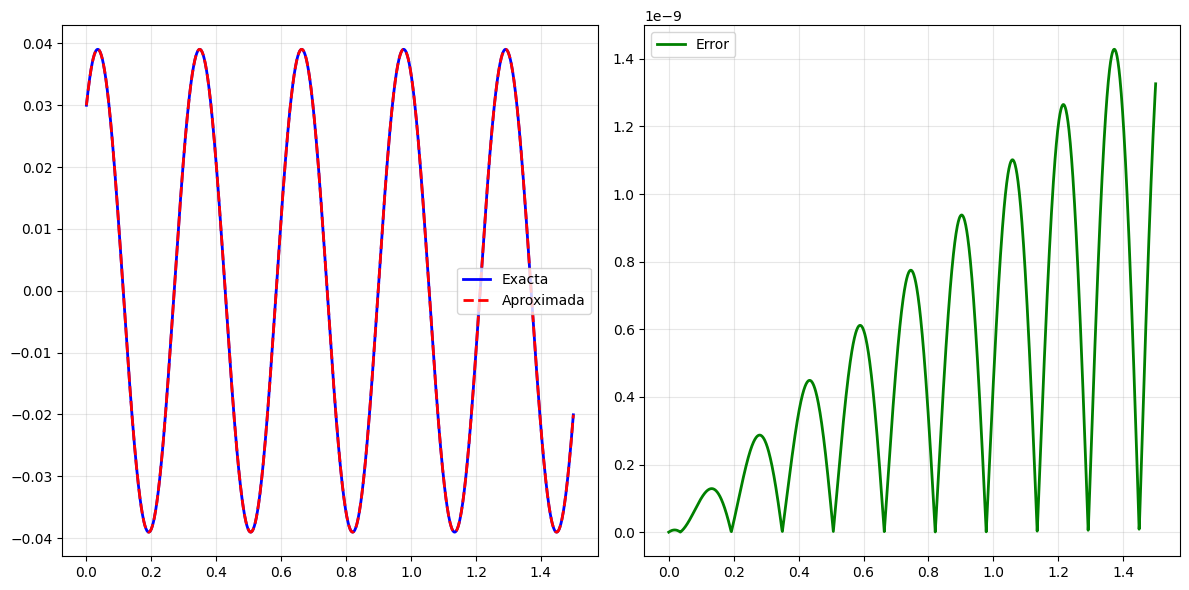

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def sistema(Y0, t):
    Y1, Y2 = Y0
    DY1 = Y2
    DY2 = -(20)**2*Y1

    return np.array([DY1, DY2])

def rk4(sistema, a, b, h, Y0):

    t = np.arange(a, b + h, h)
    n = t.shape[0]
    Y = np.zeros((n, Y0.shape[0]))
    Y[0,:] = Y0

    for i in range(n-1):
        k1 = sistema(Y[i,:],t[i])
        k2 = sistema(Y[i,:] + h*k1/2, t[i] + h/2)
        k3 = sistema(Y[i,:] + h*k2/2, t[i] + h/2)
        k4 = sistema(Y[i,:] + h*k3, t[i] + h)

        Y[i+1,:] = Y[i,:] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

    return Y, t

Y0 = np.array([0.03, 0.5])

Y, t = rk4(sistema, 0, 1.5, 0.001, Y0)

def exacta(t):
    return 0.03*np.cos(20*t) + (0.5/20)*np.sin(20*t)

Y_e = exacta(t)

error = np.abs(Y[:,0] - Y_e)

fig, ax = plt.subplots(1,2,figsize = (12,6))

ax[0].plot(t, Y_e, c = 'blue', lw = 2, label = 'Exacta')
ax[0].plot(t, Y[:,0], c = 'red', lw = 2, ls = '--', label = 'Aproximada')
ax[0].legend()

ax[0].grid(alpha = 0.3)

ax[1].plot(t, error, c = 'green', lw = 2, label = 'Error')
ax[1].legend()

ax[1].grid(alpha = 0.3)
plt.tight_layout()
plt.show()



# Métodos de paso variable

La idea de un método de paso variable es monitorear el error producido por el paso actual. El usuario establece una tolerancia al error que debe cumplirse para el paso actual. Después el método rechaza el paso y reduce el tamaño del paso si la tolerancia al error se excede o acepta el paso si se cumple y escoge un tamaño apropiado para el siguiente paso.

Supongamos que hemos encontrado la forma de aproximar el error:

Para variar el paso es posible duplicar o partir a la mitad el tamaño del paso dependiendo del error actual. Si la tolerancia no se cumple, el paso se repite con un tamaño de $h_i/2$. Si la tolerancia se cumple demasiado bien por ejemplo el error es menor a 1/10 de la tolerancia, se acepta el paso y se duplica el tamaño del paso para el siguiente paso.

Una forma más sofisticada de elegir el tamaño del paso apropiado se deduce del conocimiento del orden del método utilizdo. Suponga que el método tiene orden p, de modo que el truncamiento local es $e_i = O(h^{p+1})$. Sea T la tolerancia al error relativo permitida por el usuario para cada paso. Se debe asegurar que $\frac{e_i}{\lvert w_i \rvert} < T$.

Si se se cumple el paso se acepta y se requiere un nuevo tamaño de paso:

Si se supone que $e_i \approx ch_i^{p+1}$

Para alguna constante c, el tamaño de paso que mejor cumple la tolerancia es:

$$T\lvert w_i \rvert = ch^{p+1}$$

Al resolver se obtiene:

$$h_{*} = 0.8*\left( \frac{T\lvert w_i \rvert}{e_i}\right)^{\frac{1}{p+1}}h_i$$

Donde se añade un factor de seguridad de 0.8 para ser conservadores.

Si se cumple el objetivo, $h_{i+1} = h_{*}$. Si no se cumple, entonces: $h_{i} = h_{*}$, si aún despúes de usar este paso no se cumple la condición, se divide entre 2 h hasta conseguirlo.

Tanto los métodos simples como los sofisticados dependen de estimar $e_i = \lvert w_{i+1} - y_{i+1} \rvert$. La forma más común de lograrlo es usando un método en la solución de la EDO de orden superior en paralelo con otro método que se considere el principa. El método de orden superior para $w_{i+1}$ llámase $z_{i+1}$ será mucho más preciso que el original $w_{i+1}$, de modo que la diferencia:

$$e_{i+1} \approx \lvert z_{i+1} - w_{i+1} \rvert$$

Siguiendo esta idea se han desarrolado varios "pares" de Runge-Kutta, uno de orden p y otro de orden $p + 1$, que comparten la mayoría de los cálculos necesarios. De este modo, el costo adicional por controlar el tamaño del paso se mantiene bajo.



# Método de Runge-Kutta-Fehlberg

$$s_1 = f(t_i, w_i)$$
$$s_2 = f(t_i + \frac{1}{4}h, w_i + \frac{1}{4}hs_1)$$
$$s_3 = f(t_i + \frac{3}{8}h, w_i + \frac{3}{32}hs_1 + \frac{9}{32}hs_2)$$
$$s_4 = f(t_i + \frac{12}{13}h, w_i + \frac{1932}{2197}hs_1 - \frac{7200}{2197}hs_2 + \frac{7296}{2197}hs_3)$$
$$s_5 = f(t_i + h, w_i + \frac{439}{216}hs_1 - 8hs_2 + \frac{3680}{513}hs_3 - \frac{845}{4104}hs_4)$$
$$s_6 = f(t_i + \frac{1}{2}h, w_i - \frac{8}{27}hs_1  + 2hs_2 - \frac{3544}{2565}hs_3 + \frac{1859}{4104}hs_4 - \frac{11}{40}hs_5$$

$$w_{i+1} = w_i + h(\frac{25}{216}s_1 + \frac{1408}{2565}s_3 + \frac{2197}{4104}s_4 - \frac{1}{5}s_5)$$

$$z_{i+1} = w_i + h(\frac{16}{135}s_1 + \frac{6656}{12825}s_3 + \frac{28561}{56430}s_3 - \frac{9}{50}s_5 + \frac{2}{55}s_6)$$

$$e_{i+1} = \lvert z_{i+1} - w_{i+1} \rvert = h \lvert \frac{1}{360}s_1 - \frac{128}{4275}s_3 - {2197}{75240}s_4 + \frac{1}{50}s_5 + \frac{2}{55}s_6 \rvert$$

# Métodos implícitos y ecuaciones rígidas

Los métodos mostrados hasta ahora son explícitos, lo que significa que existe una fórmula explícita para las aproximaciones de la nueva $w_{i+1}$ en érminos de los datos conocidos, como $h, t_i, w_i$. Existe ecuaciones que no son bien abordadas por lo métodos explícitos y el primer objetivo es explicar porqué.


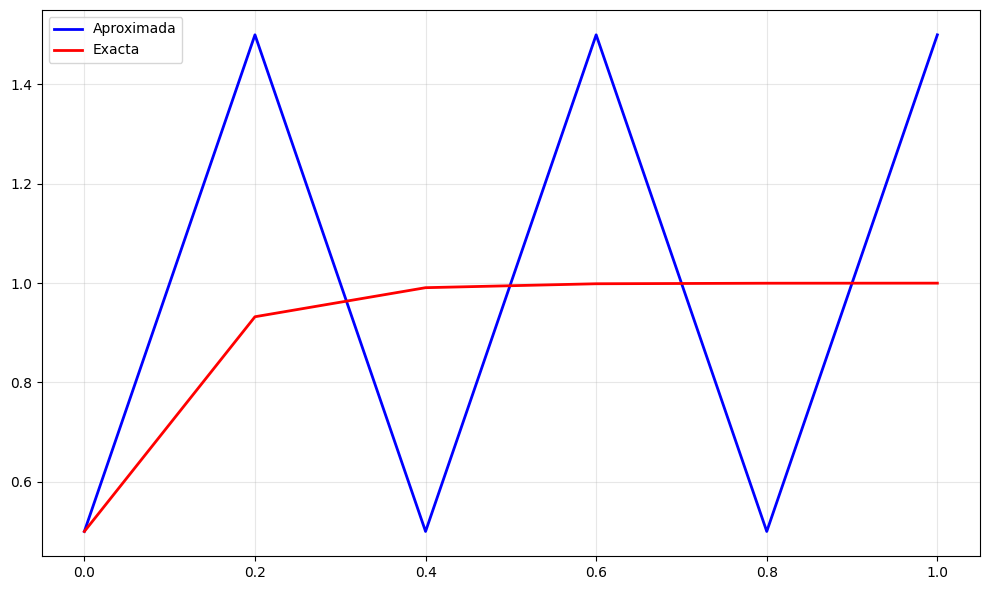

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sistema(Y0, t):
    Y1 = Y0
    DY1 = 10*(1-Y1)

    return np.array([DY1])
Y0 = np.array([1/2])

Y, t = Euler(sistema, 0, 1, 0.2, Y0)

def exacta(t):
    return 1 - np.exp(-10*t)/2

Y_e = exacta(t)

fig, ax = plt.subplots(figsize = (10,6))
ax.plot(t, Y, label = 'Aproximada', lw = 2, c = 'blue')
ax.plot(t, Y_e, label = 'Exacta', lw = 2, c = 'red')
ax.legend()
ax.grid(alpha = 0.3)
plt.tight_layout()
plt.show()



En el ejemplo anterior se abordó el PVI $y' = 10(1-y), y(0) = \frac{1}{2}, 0 \le t \le 1$. El método de Euler para este problema es:

$$w_{i+1} = w_i(1+10h) + 10h$$

Esta última ecuación puede verse como una iteración de punto fijo con:

$$g(x) = x(1+10h) + 10h$$

Esta iteración converge en el punto fijo en $x = 1$ siempre que $\lvert g'(1) \rvert = \lvert 1 - 10h \rvert \le 1$. Al resolver esta desigualdad se obtiene $0 < \le h \le 0.2$. Para cualquier h más grande, el punto fijo 1 se aleja y no tendrá solución.

Las ecuaciones con la propiedad de que las soluciones atrayantes están rodeadas de soluciones cercanas que cambian con rapidez se denominan ecuaciones rígidas. 






# Método de Euler hacia atrás

$$w_0 = y_0$$
$$w_{i+1} = w_i + hf(t_{i+1}, w_{i+1})$$

Euler hacía atrá es el primer ejemplo de un método implícito, lo que significa que el método no da directatemente una fórmula para la nueva aproximación $w_{i+1}$. Para lograrlo debe resolver el sistema.
